# 학습 & 검증
- 필요한 부분을 수정하여 사용하세요.
  

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.util import shuffle_dataset
from common.optimizer import SGD

# --- MNIST 데이터 로딩 및 전처리 ---
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# --- 학습/검증 데이터 분리 (Validation set 20%) ---
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)

# 데이터셋 셔플
x_train, t_train = shuffle_dataset(x_train, t_train)

x_train = x_train[validation_num:]
t_train = t_train[validation_num:]

x_valid = x_train[:validation_num]
t_valid = t_train[:validation_num]

# 학습용 데이터 추출
num_train = x_train.shape[0]
idx_train = np.arange(num_train)

# 검증용 데이터 추출
num_valid = x_valid.shape[0]
idx_valid = np.arange(num_valid)

# 평가용 데이터 추출
num_test = x_test.shape[0]
idx_test = np.arange(num_test)


# --- 신경망 하이퍼파라미터 설정 ---
input_size = 784                    # 입력 차원 (28x28)
output_size = 10                    # 출력 차원 (10 클래스)
hideen_size_list = [100, 50]        # 은닉층 2개

max_epochs = 100                    # Epoch 횟수
batch_size = 100                    # mini-batch 개수
learning_rate = 0.01                # 학습률
weight_decay_lambda = 0.1           # 가중치 감소 계수 (정규화 항)
activation = 'relu'
weight_init_std = 'he'              # 가중치 초기화 방식 ('xavier', 'he', 1.0)
use_batchnorm = True                # 배치 정규화 사용 여부

# --- 다층 신경망 인스턴스 생성 ---
network = MultiLayerNetExtend(
    input_size=input_size,
    hidden_size_list=hideen_size_list,
    output_size=output_size,
    activation=activation,
    weight_init_std=weight_init_std,
    weight_decay_lambda=weight_decay_lambda,
    use_batchnorm=use_batchnorm
)

# --- 옵티마이저 설정 ---
optimizer = SGD(lr=learning_rate)
# optimizer = Momentum(lr=learning_rate)
# optimizer = AdaGrad(lr=learning_rate)
# optimizer = Adam(lr=learning_rate)

# --- 학습 로그 저장용 리스트 초기화 ---
train_loss_list = []
train_acc_list = []
train_loss_per_epoch_list = []
train_acc_per_epoch_list = []

valid_loss_list = []
valid_acc_list = []
valid_loss_per_epoch_list = []
valid_acc_per_epoch_list = []

test_loss_list = []
test_acc_list = []
test_loss_per_epoch_list = []
test_acc_per_epoch_list = []

# --- 1에폭당 반복 수 계산 ---
train_per_epoch = max(num_train / batch_size, 1)
valid_per_epoch = max(num_valid / batch_size, 1)
test_per_epoch = max(num_test / batch_size, 1)

# --- 학습 루프 시작 ---
for iepoch in range(max_epochs):
    # 학습/검증 인덱스 셔플
    np.random.shuffle(idx_train)
    np.random.shuffle(idx_valid)

    train_loss = 0
    train_acc = 0
    valid_loss = 0
    valid_acc = 0

    # --- 학습 단계 ---
    for ibatch in range(0, num_train, batch_size):
        batch_mask = idx_train[ibatch:ibatch + batch_size]
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        # 손실 및 정확도 계산
        _train_loss = network.loss(x_batch, t_batch)
        _train_acc = network.accuracy(x_batch, t_batch)
        train_loss += _train_loss
        train_acc += _train_acc

        # 기울기 계산 및 파라미터 업데이트
        grads = network.gradient(x_batch, t_batch)
        optimizer.update(network.params, grads)

        # 배치 단위 기록
        train_loss_list.append(_train_loss)
        train_acc_list.append(_train_acc)

    # 에폭 단위 기록
    train_loss_per_epoch_list.append(train_loss / train_per_epoch)
    train_acc_per_epoch_list.append(train_acc / train_per_epoch)

    # --- 검증 단계 ---
    for ibatch in range(0, num_valid, batch_size):
        batch_mask = idx_valid[ibatch:ibatch + batch_size]
        x_batch = x_valid[batch_mask]
        t_batch = t_valid[batch_mask]

        # 손실 및 정확도 계산 (업데이트 없음)
        _valid_loss = network.loss(x_batch, t_batch)
        _valid_acc = network.accuracy(x_batch, t_batch)
        valid_loss += _valid_loss
        valid_acc += _valid_acc

        valid_loss_list.append(_valid_loss)
        valid_acc_list.append(_valid_acc)

    # 에폭 단위 기록
    valid_loss_per_epoch_list.append(valid_loss / valid_per_epoch)
    valid_acc_per_epoch_list.append(valid_acc / valid_per_epoch)

    # --- 로그 출력 ---
    print(f"[epoch] {iepoch} / {max_epochs} | [Train] loss:{train_loss_per_epoch_list[-1]:.4f}, acc:{train_acc_per_epoch_list[-1]:.4f} | [Valid] loss:{valid_loss_per_epoch_list[-1]:.4f}, acc:{valid_acc_per_epoch_list[-1]:.4f}")


[epoch] 0 / 100 | [Train] loss:11.3348, acc:0.7797 | [Valid] loss:6.8342, acc:0.8892
[epoch] 1 / 100 | [Train] loss:4.6039, acc:0.9127 | [Valid] loss:2.9762, acc:0.9281
[epoch] 2 / 100 | [Train] loss:2.1024, acc:0.9381 | [Valid] loss:1.4545, acc:0.9490
[epoch] 3 / 100 | [Train] loss:1.1080, acc:0.9543 | [Valid] loss:0.8376, acc:0.9618
[epoch] 4 / 100 | [Train] loss:0.7084, acc:0.9631 | [Valid] loss:0.5852, acc:0.9693
[epoch] 5 / 100 | [Train] loss:0.5427, acc:0.9683 | [Valid] loss:0.4896, acc:0.9747
[epoch] 6 / 100 | [Train] loss:0.4757, acc:0.9706 | [Valid] loss:0.4631, acc:0.9652
[epoch] 7 / 100 | [Train] loss:0.4459, acc:0.9718 | [Valid] loss:0.4370, acc:0.9727
[epoch] 8 / 100 | [Train] loss:0.4287, acc:0.9720 | [Valid] loss:0.4114, acc:0.9768
[epoch] 9 / 100 | [Train] loss:0.4177, acc:0.9724 | [Valid] loss:0.3885, acc:0.9797
[epoch] 10 / 100 | [Train] loss:0.4070, acc:0.9734 | [Valid] loss:0.3967, acc:0.9728
[epoch] 11 / 100 | [Train] loss:0.3993, acc:0.9738 | [Valid] loss:0.4061, 

# 학습 및 검증 데이터에 관한 정확도 곡선

- 필요한 부분을 수정하여 사용하세요.

<Figure size 1000x500 with 0 Axes>

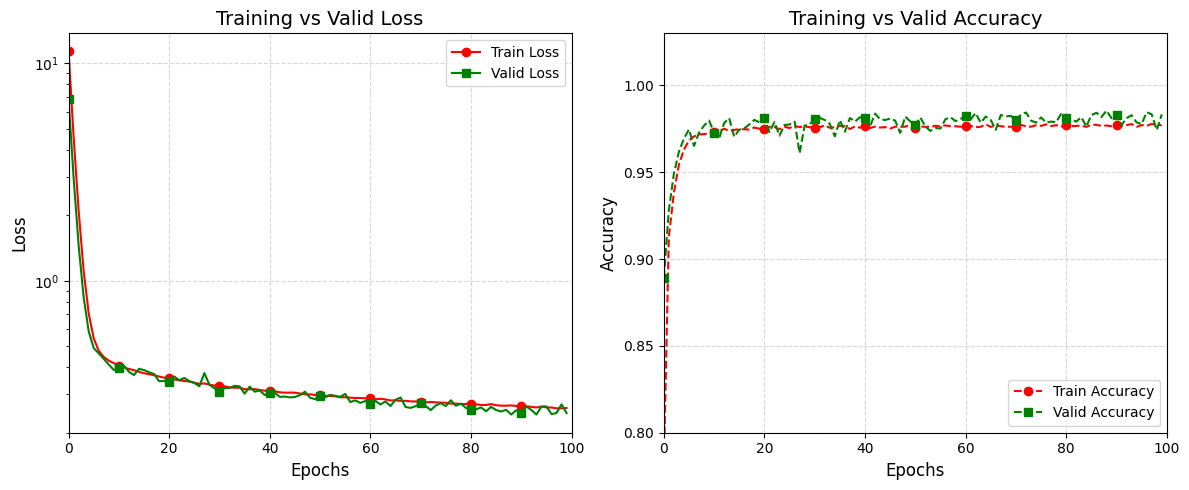

In [11]:
# --- 학습 정확도 및 검증 정확도 그래프 시각화 (subplot 사용) ---
plt.figure(figsize=(10, 5))  # 전체 그림 크기 설정 (가로 10인치, 세로 5인치)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1행 2열 서브플롯 구성
markers = {'train': 'o', 'test': 's'}

# --- 손실(loss) 시각화 (오른쪽) ---
ax = axs[0]  # 두 번째 서브플롯 (손실)

# --- 학습 손실 플롯 ---
ax.plot(
    train_loss_per_epoch_list,
    'r-', 
    marker=markers['train'],
    label='Train Loss',
    markevery=10
)

# --- 검증 손실 플롯 ---
ax.plot(
    valid_loss_per_epoch_list,
    'g-', 
    marker=markers['test'],
    label='Valid Loss',
    markevery=10
)

# --- 손실 그래프 설정 ---
ax.set_title("Training vs Valid Loss", fontsize=14)
ax.set_xlabel("Epochs", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_xlim(0, max_epochs)
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_yscale('log')

# --- 정확도 시각화 (왼쪽) ---
ax = axs[1]  # 첫 번째 서브플롯 (정확도)

# 마커 스타일 설정: 학습 데이터는 동그라미(o), 검증 데이터는 사각형(s)
markers = {'train': 'o', 'test': 's'}

# --- 학습 정확도 플롯 ---
ax.plot(
    train_acc_per_epoch_list,     # 학습 정확도 (에폭 단위)
    'r--',                         # 빨간 실선
    marker=markers['train'],      # 마커: 동그라미
    label='Train Accuracy',       
    markevery=10                  # 10에폭마다 마커 표시
)

# --- 검증 정확도 플롯 ---
ax.plot(
    valid_acc_per_epoch_list,     # 검증 정확도 (에폭 단위)
    'g--',                        # 초록 점선
    marker=markers['test'],       # 마커: 사각형
    label='Valid Accuracy',
    markevery=10
)

# --- 정확도 그래프 설정 ---
ax.set_title("Training vs Valid Accuracy", fontsize=14)
ax.set_xlabel("Epochs", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_ylim(0.8, 1.03)
ax.set_xlim(0, max_epochs)
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)

# 전체 레이아웃 정리 및 출력
plt.tight_layout()
plt.show()


# 평가
- 필요한 부분을 수정하여 사용하세요.
  

In [12]:
# --- 테스트 손실 및 정확도 초기화 ---
test_loss = 0  # 전체 테스트 손실 누적 변수
test_acc = 0   # 전체 테스트 정확도 누적 변수

# --- 테스트 평가 단계 시작 ---
for ibatch in range(0, num_test, batch_size):
    _ibatch = ibatch + batch_size  # 미니배치 끝 인덱스
    if _ibatch >= num_test: 
        _ibatch = num_test  # 마지막 배치 처리 (데이터 초과 방지)

    batch_mask = idx_test[ibatch:_ibatch]  # 미니배치 인덱스 추출
    x_batch = x_test[batch_mask]           # 입력 데이터 추출
    t_batch = t_test[batch_mask]           # 정답 레이블 추출

    # --- 손실 및 정확도 계산 (모델 파라미터 업데이트 없음) ---
    _test_loss = network.loss(x_batch, t_batch)       # 손실 계산
    _test_acc = network.accuracy(x_batch, t_batch)     # 정확도 계산

    test_loss += _test_loss   # 손실 누적
    test_acc += _test_acc     # 정확도 누적

    test_loss_list.append(_test_loss)  # 배치 단위 손실 저장
    test_acc_list.append(_test_acc)    # 배치 단위 정확도 저장

# --- 전체 테스트 세트에 대한 평균 손실 및 정확도 계산 ---
test_loss_per_epoch_list.append(test_loss / test_per_epoch)
test_acc_per_epoch_list.append(test_acc / test_per_epoch)

# --- 테스트 결과 출력 ---
print(f"[Test] loss:{test_loss_per_epoch_list[-1]:.4f}, acc:{test_acc_per_epoch_list[-1]:.4f}")


[Test] loss:0.2745, acc:0.9712


# 샘플 이미지 평가
- 필요한 부분을 수정하여 사용하세요.
  

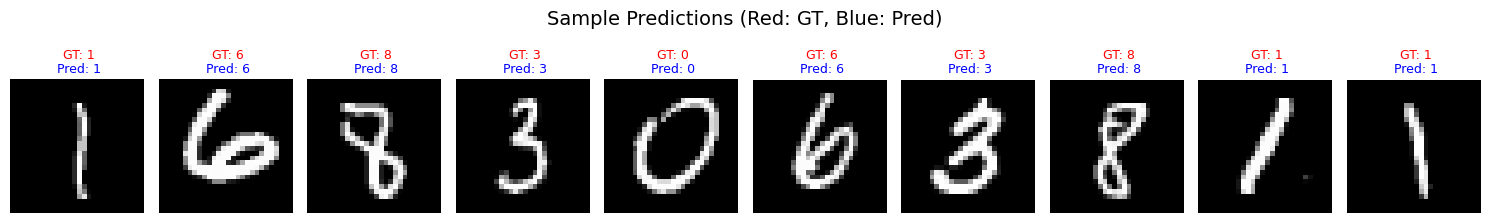

In [13]:
import matplotlib.pyplot as plt

# --- 테스트 데이터에서 샘플 추출 ---
num_samples = 10
sample_idx = np.random.choice(num_test, num_samples, replace=False)
x_sample = x_test[sample_idx]
t_sample = t_test[sample_idx]

# --- 모델 예측 ---
y_pred = network.predict(x_sample)
y_pred_label = np.argmax(y_pred, axis=1)
t_label = t_sample if t_sample.ndim == 1 else np.argmax(t_sample, axis=1)

# --- 시각화 ---
plt.figure(figsize=(15, 2.5))
for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    image = x_sample[i].reshape(28, 28)
    plt.imshow(image, cmap='gray')

    # 빨간색 GT 텍스트
    plt.text(14, -5, f"GT: {t_label[i]}", color='red',
             fontsize=9, ha='center', transform=plt.gca().transData)
    
    # 파란색 Pred 텍스트
    plt.text(14, -2, f"Pred: {y_pred_label[i]}", color='blue',
             fontsize=9, ha='center', transform=plt.gca().transData)

    plt.axis('off')

plt.suptitle("Sample Predictions (Red: GT, Blue: Pred)", fontsize=14)
plt.tight_layout()
plt.show()
